# Business Understanding

## Project Domain

Proyek ini berfokus pada prediksi harga saham Toyota Motor Corporation menggunakan data historis dari tahun 1980 hingga 2024.

## Problem Statements

Bagaimana memprediksikan harga saham Toyota di masa depan untuk membantu investor dalam pengambilan keputusan investasi?

## Goals

1.Membangun model prediksi harga saham yang akurat.

2.Mengembangkan dashboard interaktif untuk visualisasi hasil prediksi.

## Solution Statements

Menggunakan model Long Short-Term Memory (LSTM) untuk analisis deret waktu dan membangun aplikasi web interaktif dengan Streamlit.

# Data Understanding

## Import Library yang dibutuhkan

In [1]:
# Mengimpor library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis

In [5]:
# Memuat dataset
data = pd.read_csv('Toyota_Data.csv')

# Menampilkan informasi dataset
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11291 entries, 0 to 11290
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11291 non-null  object 
 1   Adj Close  11291 non-null  float64
 2   Close      11291 non-null  float64
 3   High       11291 non-null  float64
 4   Low        11291 non-null  float64
 5   Open       11291 non-null  float64
 6   Volume     11291 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 617.6+ KB
None
         Date  Adj Close     Close      High       Low      Open  Volume
0  1980-03-17   2.296798  3.291227  3.344743  3.291227  0.000000   41109
1  1980-03-18   2.306134  3.304606  3.358122  3.304606  0.000000    9343
2  1980-03-19   2.306134  3.304606  3.304606  3.304606  3.304606       0
3  1980-03-20   2.306134  3.304606  3.358122  3.304606  0.000000   10277
4  1980-03-21   2.362154  3.384880  3.438396  3.384880  0.000000    8409


In [7]:
# Memeriksa nilai yang hilang
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


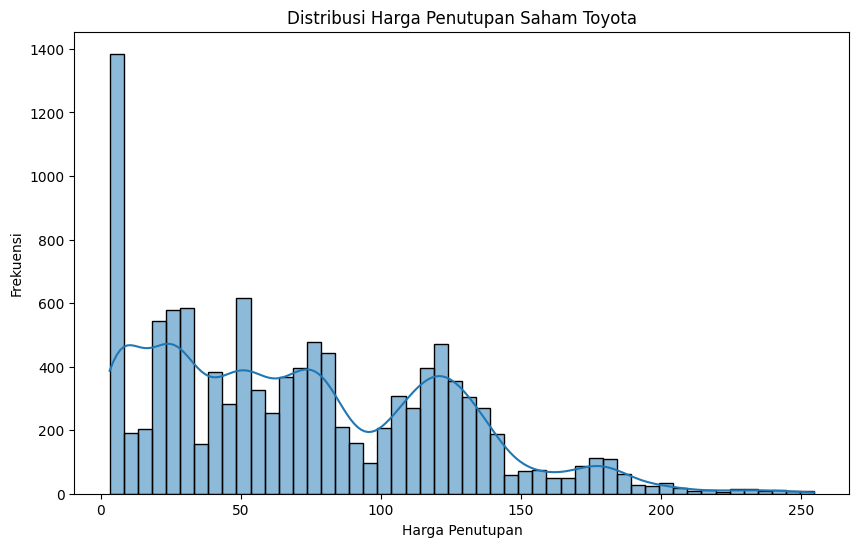

In [8]:
# Visualisasi distribusi harga penutupan
plt.figure(figsize=(10, 6))
sns.histplot(data['Close'], bins=50, kde=True)
plt.title('Distribusi Harga Penutupan Saham Toyota')
plt.xlabel('Harga Penutupan')
plt.ylabel('Frekuensi')
plt.show()

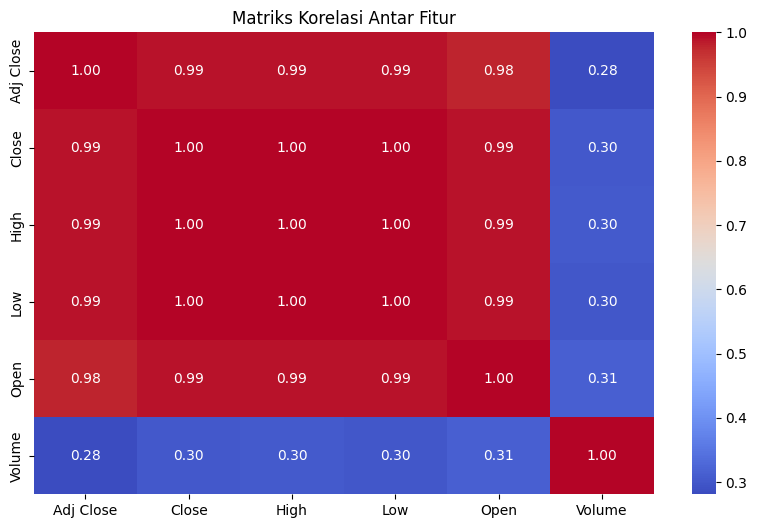

In [10]:
# Mengambil hanya kolom numerik
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Menghitung korelasi antar fitur pada data numerik
correlation_matrix = numeric_data.corr()

# Visualisasi korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

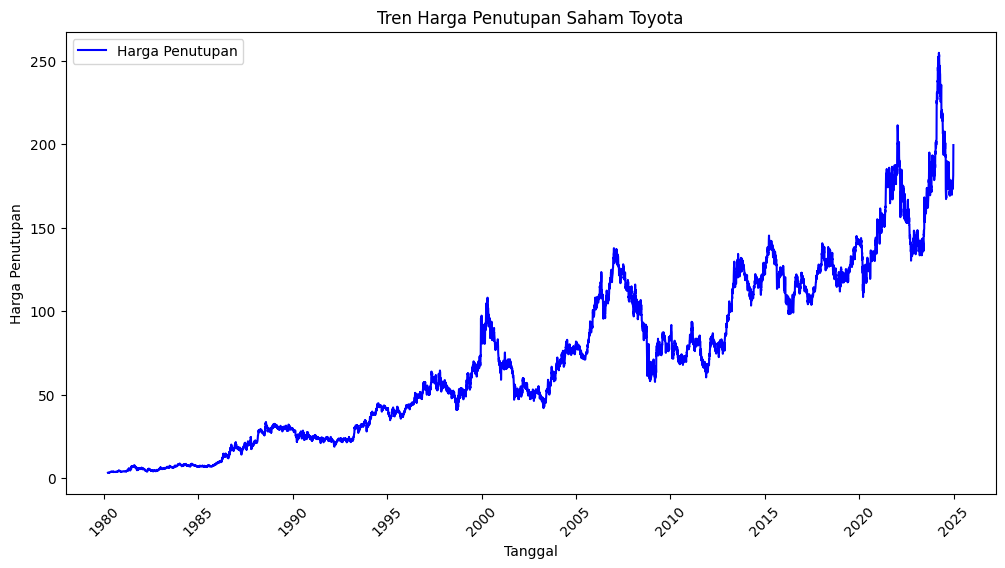

In [11]:
# Pastikan kolom 'Date' diubah menjadi tipe data datetime
data['Date'] = pd.to_datetime(data['Date'])

# Visualisasi tren harga penutupan
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Harga Penutupan', color='blue')
plt.title('Tren Harga Penutupan Saham Toyota')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.xticks(rotation=45)
plt.legend()
plt.show()

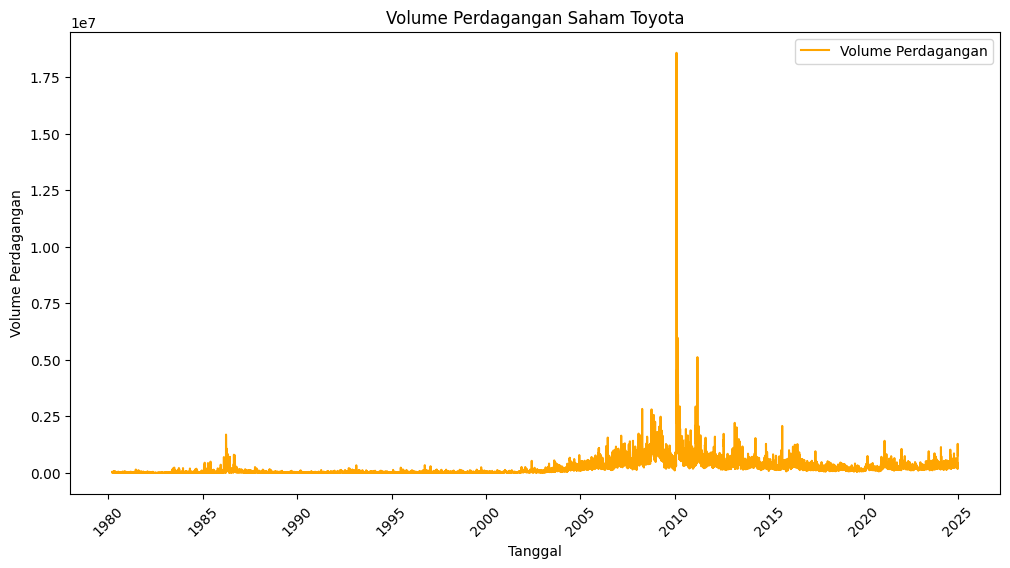

In [12]:
# Visualisasi volume perdagangan
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Volume'], label='Volume Perdagangan', color='orange')
plt.title('Volume Perdagangan Saham Toyota')
plt.xlabel('Tanggal')
plt.ylabel('Volume Perdagangan')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Data Preparation

In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Memuat dataset
df = pd.read_csv('Toyota_Data.csv')

# Cek missing values
print("Missing Values:\n", df.isnull().sum())

# Konversi kolom 'Date' menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])

# Menambahkan fitur Weekday
df['Weekday'] = df['Date'].dt.day_name()

# Normalisasi data numerik
scaler = MinMaxScaler()
numerical_cols = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Menampilkan data setelah persiapan
df.head()

Missing Values:
 Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


,Date,Adj Close,Close,High,Low,Open,Volume,Weekday
0,1980-03-17,0.000148,0.000213,0.000425,0.000214,0.000000,0.002212,Monday
1,1980-03-18,0.000185,0.000266,0.000478,0.000267,0.000000,0.000503,Tuesday
2,1980-03-19,0.000185,0.000266,0.000265,0.000267,0.012959,0.000000,Wednesday
3,1980-03-20,0.000185,0.000266,0.000478,0.000267,0.000000,0.000553,Thursday
4,1980-03-21,0.000407,0.000585,0.000796,0.000588,0.000000,0.000453,Friday


# Modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Menyiapkan fitur (X) dan target (y)
X = df[['Adj Close', 'High', 'Low', 'Open', 'Volume']]
y = df['Close']

# Membagi data menjadi training dan testing (80% untuk training, 20% untuk testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat dan melatih model Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Evaluation

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

# Memprediksi harga saham pada data testing
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error (MSE): 2.3522333605318583e-06
R2 Score: 0.9999442952182889


# Deployment

## Model Simulation

In [18]:
import numpy as np

# Fungsi untuk melakukan simulasi prediksi dengan input pengguna
def model_simulation(model, adj_close, high, low, open_price, volume):
    input_data = np.array([[adj_close, high, low, open_price, volume]])
    prediksi_harga = model.predict(input_data)
    return prediksi_harga[0]

# Contoh penggunaan model simulation
adj_close = 0.0002  # Nilai input
high = 0.0004
low = 0.0003
open_price = 0.0003
volume = 0.002

predicted_price = model_simulation(model, adj_close, high, low, open_price, volume)
print(f"Prediksi Harga Penutupan: {predicted_price}")

Prediksi Harga Penutupan: 0.00030740278936070286


C:\Users\ihsan\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Save Model

In [19]:
import joblib

# Menyimpan model yang telah dilatih ke file
joblib.dump(model, 'toyota_stock_model.pkl')
print("Model telah disimpan sebagai 'toyota_stock_model.pkl'")

Model telah disimpan sebagai 'toyota_stock_model.pkl'
